In [1]:
from dotenv import load_dotenv
load_dotenv()

True

# Step 1 - Data Ingest

In [2]:
import os
from langchain_openai import ChatOpenAI
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm = ChatOpenAI(model=os.getenv("LLM_MODEL"))

In [3]:
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-large"
)

In [4]:
urls=[
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    'https://lilianweng.github.io/posts/2025-05-01-thinking/',
    'https://lilianweng.github.io/posts/2024-07-07-hallucination/',
    'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/',
]

In [5]:
from langchain_community.document_loaders import WebBaseLoader
docs=[WebBaseLoader(url).load() for url in urls]
docs_list=[item for sublist in docs for item in sublist] # flatten the list of lists into a single list to parse it further into split_documents

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter 
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100,chunk_overlap=25) 
doc_splits=text_splitter.split_documents(docs_list)

# This line creates a text splitter that:
# Uses OpenAI's tiktoken tokenizer to determine how many tokens are in each chunk (instead of using character counts).
# Splits text into chunks of ~100 tokens, not characters.
# Ensures 25 tokens of overlap between each chunk (so important context is preserved across chunks).

# Why is this useful?
# LLMs process input in tokens, not characters. Token-based splitting ensures that:
# You don’t accidentally cut off semantic meaning mid-token.
# This is especially important when using OpenAI models, since token count determines cost and performance.

In [8]:
from langchain_community.vectorstores import Chroma
vectorstore=Chroma.from_documents(
    documents=doc_splits, # we create an in-memory vector store (we first split the documents into chunks and then we embed them)
    collection_name="rag-chroma", # we name the collection
    embedding=embeddings # openai embeddings
)

# Step 2 - Data Retriever 
Get input query, embed it and look for similarities in vector DB

In [10]:
from langchain.tools.retriever import create_retriever_tool # you can create a @tool by wrapping retriever into a function OR you can use the function directly
retriever=vectorstore.as_retriever()
retriever_tool=create_retriever_tool(
    retriever,
    "retriever_blog_post",
    "You are an expert in LLM and Tech. Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, why we think, Extrinsic Hallucinations in LLMs, and adversarial attacks on LLMs.You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to blog data. For all other queries, respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.",
    )

In [11]:
from langgraph.prebuilt import ToolNode
tools=[retriever_tool]
retriever_node=ToolNode(tools) # we always need to wrap tools in a ToolNode

In [12]:
from typing import Annotated,Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [13]:
from langchain_core.prompts import PromptTemplate
def LLM_Decision_Maker(state:AgentState): # END or RETRIEVER
    print("----CALL LLM_DECISION_MAKE----")
    llm_with_tool=llm.bind_tools(tools)
    message=state["messages"]
    last_message=message[-1]
    question=last_message.content
    response=llm_with_tool.invoke(question)
    return {"messages":[response]}

In [14]:
from pydantic import BaseModel, Field
from typing import Literal
class grade(BaseModel): # pydantic class
    binary_score: Literal["yes", "no"] = Field(description="Relevance score 'yes' or 'no'") # Field is the place where you write down description

In [15]:
#we use it for type of hinting
def grade_documents(state:AgentState)->Literal["generator", "rewriter"]: # return either one or another 
    print("----CALLING GRADE FOR CHECKING RELEVANCY----")
    llm_with_structure_op=llm.with_structured_output(grade) # with_structured_output - Model wrapper that returns outputs formatted to match the given schema.
    
    prompt=PromptTemplate(
        template="""You are a grader deciding if a document is relevant to a user’s question.
                    Here is the document: {context}
                    Here is the user’s question: {question}
                    If the document talks about or contains information related to the user’s question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
                    input_variables=["context", "question"]
                    )
     
    chain=prompt|llm_with_structure_op
     
     
    message=state['messages']
    
    last_message = message[-1]
    
    question = message[0].content # initial user query
    
    docs = last_message.content # retrieved docs which are in the last message state (previous step was RAG)
    
    scored_result=chain.invoke({"question": question, "context": docs})
    
    score=scored_result.binary_score # we get the score from the pydantic class - we defined it inside the grade class
    # we know for sure that we get output in this format BECAUSE we told llm to return structured output
     
    if score=="yes":
        print("----DECISION: DOCS ARE RELEVANT----")
        return "generator" # these exact return names will be used as references later in the conditional edge construction
    else:
        print("----DECISION: DOCS ARE NOT RELEVANT----")
        return "rewriter"

In [17]:
from langchain_core.messages import HumanMessage
def rewrite(state:AgentState):
    print("----TRANSFORM QUERY----")
    message=state["messages"]
    
    question=message[0].content # first message - user query
    
    input= [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]

    response=llm.invoke(input)
    
    return {"messages": [response]} # HERE WE RETURN THE REWRITTEN QUERY - and this query already goes to the very beginning of the workflow
    

In [27]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import AIMessage
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
def web_search(state:AgentState):
    print("----WEB SEARCH----")
    message=state["messages"]
    rewritten_query=message[-1].content # first message - user query
    search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)
    response=search_tool.invoke(rewritten_query)

    # Convert the list response to a proper message format
    formatted_response = AIMessage(content=str(response))
    
    return {"messages": [formatted_response]}

In [21]:
from langchain import hub
def generate(state:AgentState):
  print("----OUTPUT GENERATE----")
  
  message=state["messages"]
  question=message[0].content # user question
  
  last_message = message[-1] # these are extracted documents from RAG OR WEB SEARCH
  docs = last_message.content 
  prompt=hub.pull("rlm/rag-prompt")
  output_chain=prompt | llm
  response=output_chain.invoke({"context": docs, "question": question})
  
  print(f"this is my response:{response}")
  return {"messages": [response]}

In [28]:
from langgraph.graph import END, StateGraph, START
workflow=StateGraph(AgentState)
workflow.add_node("LLM Decision Maker",LLM_Decision_Maker)
workflow.add_node("Vector Retriever",retriever_node) # embed user query and find relevant docs
workflow.add_node("Output Generator",generate) # generate answer based on relevant docs
workflow.add_node("Query Rewriter",rewrite) # rewrite query to be more specific
workflow.add_node("WEB Search",web_search) # rewrite query to be more specific

In [29]:
from langgraph.prebuilt import tools_condition
workflow.add_edge(START,"LLM Decision Maker")
workflow.add_conditional_edges("LLM Decision Maker",
                               tools_condition,
                               {"tools":"Vector Retriever",
                                END:END
                                })
# tools_condition - inbuild tool condition instead of your custom router function
# it either ends the conversation (if not relevant)or goes to the vector retriever node

workflow.add_conditional_edges("Vector Retriever",
                               grade_documents,
                               {"generator":"Output Generator", # "generator" and "rewriter" are outputs from the grade_documents function
                                "rewriter":"Query Rewriter"
                                })
# here, if tools_condition decided to go to Vector Retriever, it will choose either to 
# generate the output OR to rewrite the query
workflow.add_edge("Output Generator",END)
# if we got output generator, then we are done
workflow.add_edge("Query Rewriter","WEB Search")
workflow.add_edge("WEB Search","Output Generator")
app=workflow.compile()

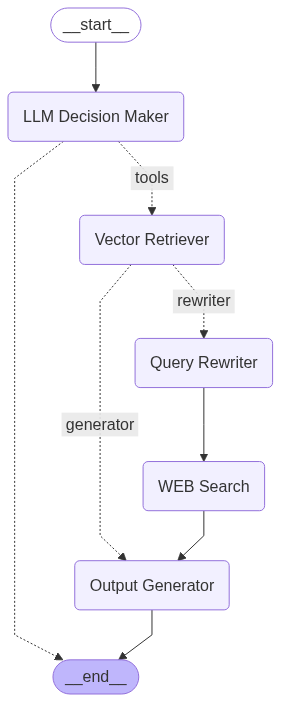

In [30]:
app

In [31]:
import warnings
warnings.filterwarnings("ignore")

In [32]:
app.invoke({"messages":["what is LLM Powered Autonomous Agents defined in LangChain blog?"]})
# with complex queries it can even split the query into multiple retrievals based on the topics asked.

----CALL LLM_DECISION_MAKE----
----CALLING GRADE FOR CHECKING RELEVANCY----
----DECISION: DOCS ARE NOT RELEVANT----
----TRANSFORM QUERY----
----WEB SEARCH----
----OUTPUT GENERATE----
this is my response:content='LLM Powered Autonomous Agents, as defined in the LangChain blog, are systems that use a large language model (LLM) to decide the control flow of an application autonomously. They independently determine which actions to take and execute tasks without human intervention by integrating with tools, APIs, and managing workflows dynamically. These agents extend LLM capabilities by enabling reasoning, interaction with environments, and complex task completion.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 1219, 'total_tokens': 1300, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'ca

{'messages': [HumanMessage(content='what is LLM Powered Autonomous Agents defined in LangChain blog?', additional_kwargs={}, response_metadata={}, id='cb261832-c201-4517-9594-1df84b76b14e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_OnMbYj6a0qAi98dWyUnwTIsF', 'function': {'arguments': '{"query":"LLM Powered Autonomous Agents LangChain blog"}', 'name': 'retriever_blog_post'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 160, 'total_tokens': 184, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_6f2eabb9a5', 'id': 'chatcmpl-BmYCkD8lUtZk6qYLHhWzp7xlJrq4F', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--53f9ff55-8e42-4154-a5e5-de9107

In [33]:
app.invoke({"messages":["hi how are you gpt?"]})

----CALL LLM_DECISION_MAKE----


{'messages': [HumanMessage(content='hi how are you gpt?', additional_kwargs={}, response_metadata={}, id='16fee6db-0dee-42e9-bcaa-c26fa5c2a5ea'),
  AIMessage(content="Hello! I'm just a bunch of code, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 154, 'total_tokens': 186, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_6f2eabb9a5', 'id': 'chatcmpl-BmYD76lCADM0zVLsqY545LZDNjyCr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--9b21b4c8-3f13-4e86-b3d4-6040524a8e57-0', usage_metadata={'input_tokens': 154, 'output_tokens': 32, 'total_tokens': 186, 'input_token_details': {'audio': 0

In [34]:
question="can you explain me what is a task decomposition and why Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks?"
app.invoke({"messages":[question]})

----CALL LLM_DECISION_MAKE----


{'messages': [HumanMessage(content='can you explain me what is a task decomposition and why Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks?', additional_kwargs={}, response_metadata={}, id='9200900e-5203-4190-98e0-05edb01404ec'),
  AIMessage(content='Task decomposition refers to the process of breaking down a complex task into smaller, more manageable subtasks or steps. This approach helps in understanding, solving, and reasoning about the task more effectively, as it allows focusing on individual components one at a time instead of tackling the entire task in one go.\n\nChain of Thought (CoT) prompting is a technique introduced by Wei et al. (2022) that involves guiding a language model to generate intermediate reasoning steps or a sequence of thoughts before producing the final answer. Essentially, the model is prompted to "think aloud" or show its reasoning process, which mirrors how humans solve com